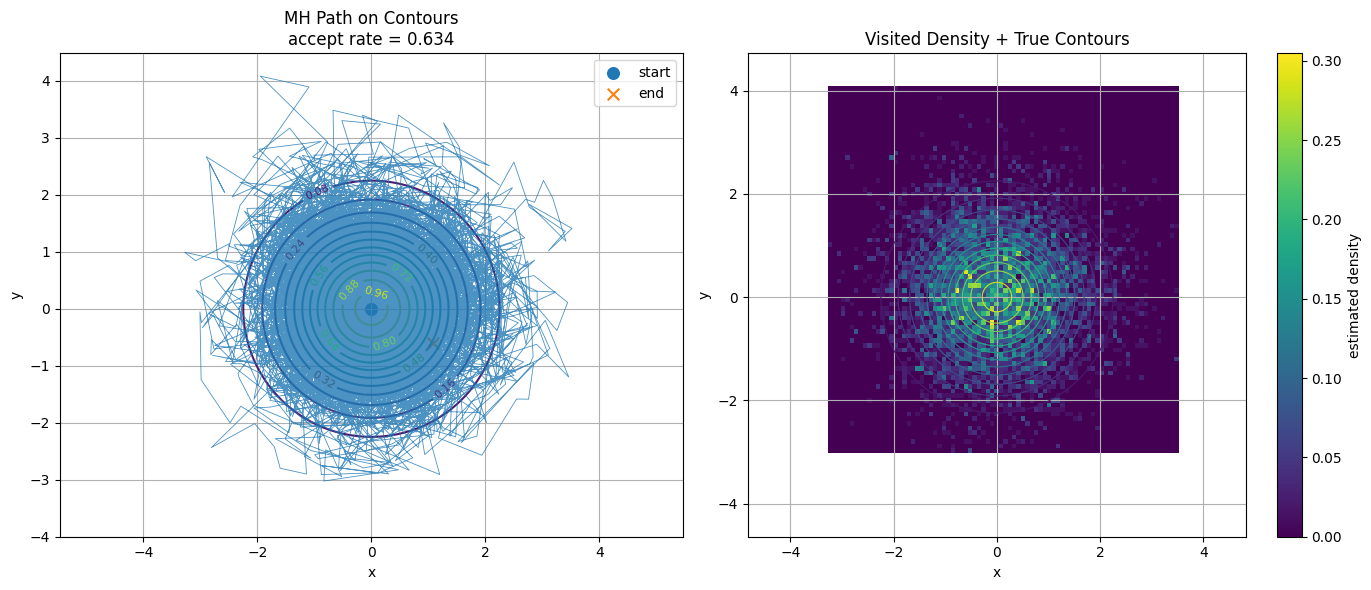

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 設定
# =========================================
np.random.seed(42)
n_steps = 10000
proposal_std = 0.8

def log_target(x):
    return -0.5 * (x[0]**2 + x[1]**2)

def target_density(x, y):
    return np.exp(-0.5 * (x**2 + y**2))

# =========================================
# MHサンプリング
# =========================================
mh = np.zeros((n_steps, 2))
current = np.array([0.0, 0.0])
accepted = 0

for t in range(1, n_steps):
    proposal = current + np.random.normal(0, proposal_std, size=2)
    log_alpha = log_target(proposal) - log_target(current)

    if np.log(np.random.rand()) < log_alpha:
        current = proposal
        accepted += 1

    mh[t] = current

accept_rate = accepted / (n_steps - 1)

# =========================================
# 等高線用
# =========================================
x = np.linspace(-4, 4, 250)
y = np.linspace(-4, 4, 250)
X, Y = np.meshgrid(x, y)
Z = target_density(X, Y)

# =========================================
# 描画
# =========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- 左: 等高線 + 軌跡 ----
cs = axes[0].contour(X, Y, Z, levels=12)
axes[0].clabel(cs, inline=True, fontsize=8)
axes[0].plot(mh[:, 0], mh[:, 1], linewidth=0.6, alpha=0.8)
axes[0].scatter(mh[0, 0], mh[0, 1], s=70, marker='o', label='start')
axes[0].scatter(mh[-1, 0], mh[-1, 1], s=70, marker='x', label='end')
axes[0].set_title(f"MH Path on Contours\naccept rate = {accept_rate:.3f}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].axis("equal")
axes[0].grid(True)
axes[0].legend()

# ---- 右: 訪問頻度ヒートマップ ----
h = axes[1].hist2d(mh[:, 0], mh[:, 1], bins=80, density=True)
axes[1].contour(X, Y, Z, levels=12, linewidths=0.8)
axes[1].set_title("Visited Density + True Contours")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].axis("equal")
axes[1].grid(True)

plt.colorbar(h[3], ax=axes[1], label="estimated density")
plt.tight_layout()
plt.show()